# A √2 in the attention scale sat silent for 47,213 steps

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## How much sharper is a head at temperature 0.71?

In [1]:
import numpy as np

def softmax(x, axis=-1):
    """Numerically stable softmax along given axis."""
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

rng = np.random.default_rng(0)
n, d_true, d_cfg = 512, 128, 64
Q = rng.standard_normal((n, d_true))
K = rng.standard_normal((n, d_true))

for growth in (1, 2):
    for label, d in (("correct 1/sqrt(128)", d_true), ("bug     1/sqrt(64) ", d_cfg)):
        S = (growth * Q) @ (growth * K).T / np.sqrt(d)
        A = softmax(S)
        H = -(A * np.log(A + 1e-30)).sum(-1).mean()
        print(f"norm x{growth}  {label}  logit std {S.std():5.2f}  "
              f"max weight {A.max(-1).mean():.3f}  entropy {H:.2f} nats")

norm x1  correct 1/sqrt(128)  logit std  1.00  max weight 0.027  entropy 5.74 nats
norm x1  bug     1/sqrt(64)   logit std  1.42  max weight 0.060  entropy 5.25 nats
norm x2  correct 1/sqrt(128)  logit std  4.01  max weight 0.456  entropy 2.10 nats
norm x2  bug     1/sqrt(64)   logit std  5.67  max weight 0.605  entropy 1.33 nats


## Measuring the spike

In [2]:
V = rng.standard_normal((n, d_true))
dO = rng.standard_normal((n, d_true))          # upstream gradient at the output
dA = dO @ V.T                                  # dL/dA
for growth in (1, 2, 4):
    for label, d in (("correct", d_true), ("bug    ", d_cfg)):
        Kg = growth * K
        A = softmax((growth * Q) @ Kg.T / np.sqrt(d))
        dS = A * (dA - (A * dA).sum(-1, keepdims=True))   # softmax backward
        g = np.linalg.norm(dS @ Kg / np.sqrt(d), axis=1)  # |dL/dq| per query
        top2 = np.sort(A[g.argmax()])[::-1][:2]
        print(f"norm x{growth}  {label}  saturated {(A.max(-1) > 0.99).mean():.2f}  "
              f"global |dQ| {np.linalg.norm(g):5.1f}  "
              f"median |dq| {np.median(g):5.2f}  max |dq| {g.max():5.2f}  "
              f"top-2 weights of worst query {top2.round(2)}")

norm x1  correct  saturated 0.00  global |dQ|  18.7  median |dq|  0.79  max |dq|  1.89  top-2 weights of worst query [0.07 0.03]
norm x1  bug      saturated 0.00  global |dQ|  40.1  median |dq|  1.55  max |dq|  6.37  top-2 weights of worst query [0.19 0.06]
norm x2  correct  saturated 0.01  global |dQ| 151.7  median |dq|  5.35  max |dq| 24.58  top-2 weights of worst query [0.33 0.24]
norm x2  bug      saturated 0.05  global |dQ| 219.6  median |dq|  7.00  max |dq| 40.72  top-2 weights of worst query [0.44 0.28]
norm x4  correct  saturated 0.39  global |dQ| 243.6  median |dq|  1.64  max |dq| 49.34  top-2 weights of worst query [0.52 0.47]
norm x4  bug      saturated 0.50  global |dQ| 304.9  median |dq|  0.62  max |dq| 70.04  top-2 weights of worst query [0.53 0.46]


## The figure

In [3]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

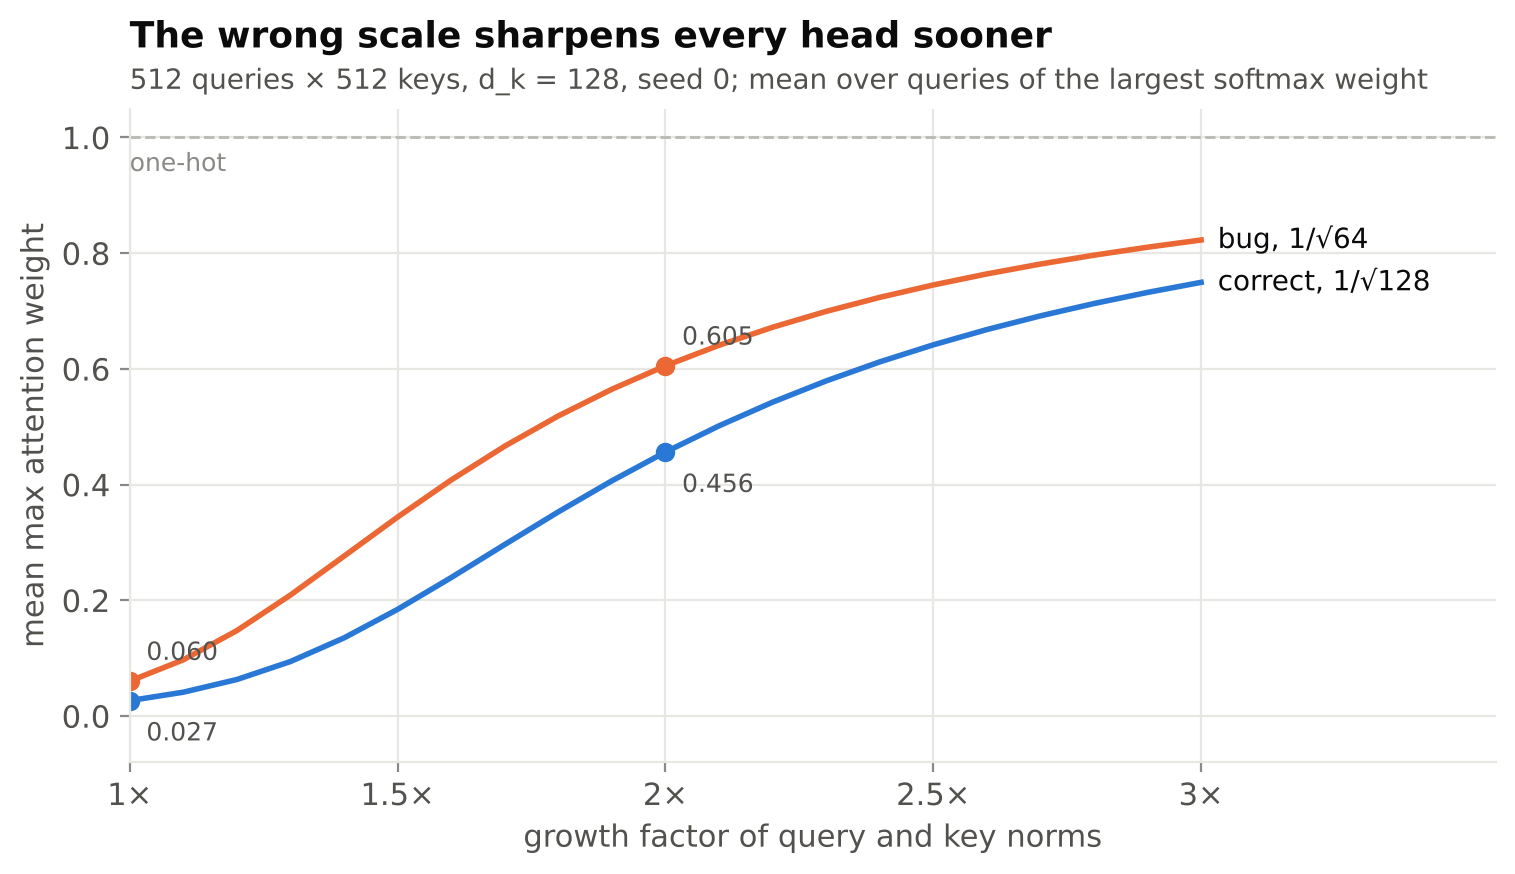

In [4]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np


    def softmax(x, axis=-1):
        x = x - x.max(axis=axis, keepdims=True)
        e = np.exp(x)
        return e / e.sum(axis=axis, keepdims=True)


    rng = np.random.default_rng(0)                 # same seeded setup as the article
    n, d_true, d_cfg = 512, 128, 64
    Q = rng.standard_normal((n, d_true))
    K = rng.standard_normal((n, d_true))

    growths = np.round(np.arange(1.0, 3.001, 0.1), 2)
    res = {}
    for d in (d_true, d_cfg):
        res[d] = [softmax((g * Q) @ (g * K).T / np.sqrt(d)).max(-1).mean() for g in growths]

    f, ax = fig()
    ax.axhline(1.0, color=NEUTRAL, lw=1, ls="--")
    ax.text(1.0, 0.975, "one-hot", color=MUTED, fontsize=9, va="top")
    for d, c, name in ((d_true, S1, "correct, 1/√128"), (d_cfg, S2, "bug, 1/√64")):
        y = np.array(res[d])
        ax.plot(growths, y, color=c)
        for g in (1.0, 2.0):
            i = int(np.argmin(abs(growths - g)))
            ax.plot(g, y[i], "o", color=c, ms=6)
            dy = 10 if d == d_cfg else -12
            ax.annotate(f"{y[i]:.3f}", (g, y[i]), xytext=(6, dy), textcoords="offset points",
                        color=INK_2, fontsize=9, va="center")
        label_end(ax, growths[-1], y[-1], name, c, dx=6)
    ax.set_xlim(1.0, 3.55)
    ax.set_xticks([1, 1.5, 2, 2.5, 3])
    ax.set_xticklabels(["1×", "1.5×", "2×", "2.5×", "3×"])
    ax.set_ylim(-0.08, 1.05)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xlabel("growth factor of query and key norms")
    ax.set_ylabel("mean max attention weight")
    ax.set_title("The wrong scale sharpens every head sooner")
    subtitle(ax, "512 queries × 512 keys, d_k = 128, seed 0; mean over queries of the largest softmax weight")
    save(f, pathlib.Path(__file__).parent / "01-attention-sharpness.png")
    for d in res: print(d, [f"{v:.3f}" for v in res[d]])
import matplotlib.pyplot as plt
plt.show()